In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from optbinning import OptimalBinning, BinningProcess
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

In [5]:
df = pd.read_csv("../data/credit_risk_dataset.csv", sep=',')
df = df[df["person_age"]<=100]
df = df[(df["person_emp_length"]<=41)|(df["person_emp_length"].isna())]

In [6]:
column_num = df.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df.select_dtypes(include=['object']).columns.drop('loan_grade')

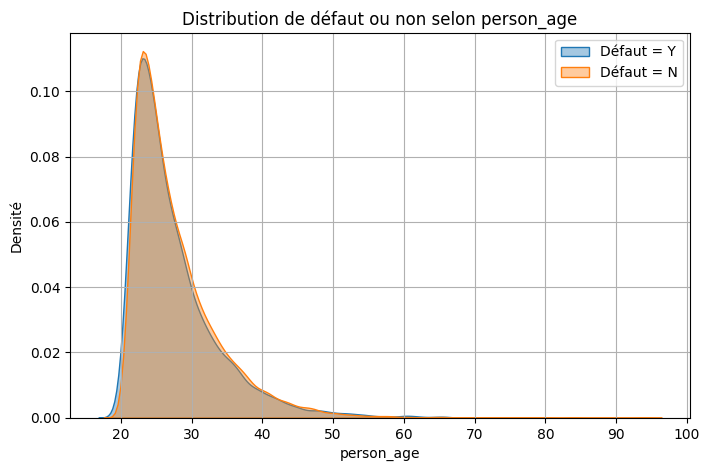

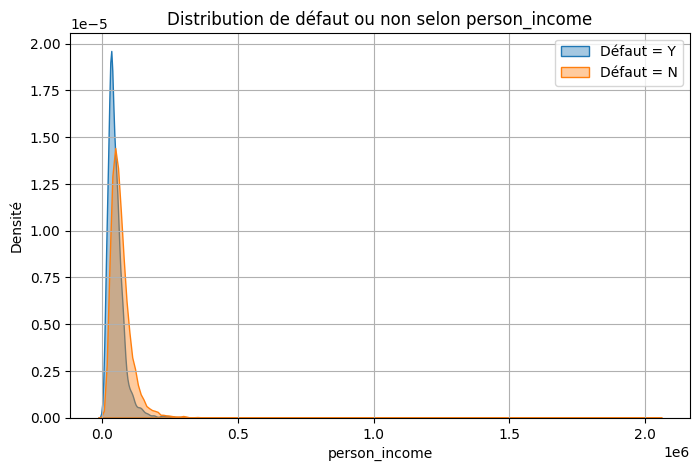

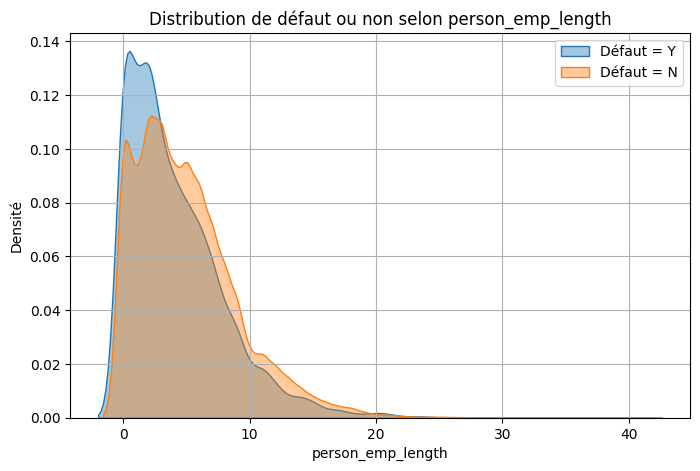

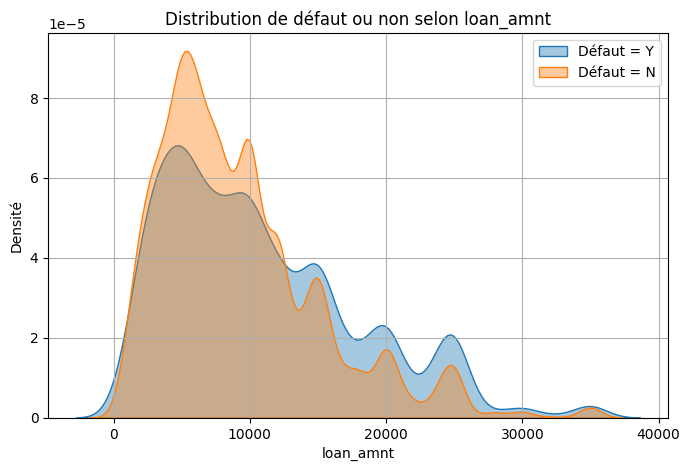

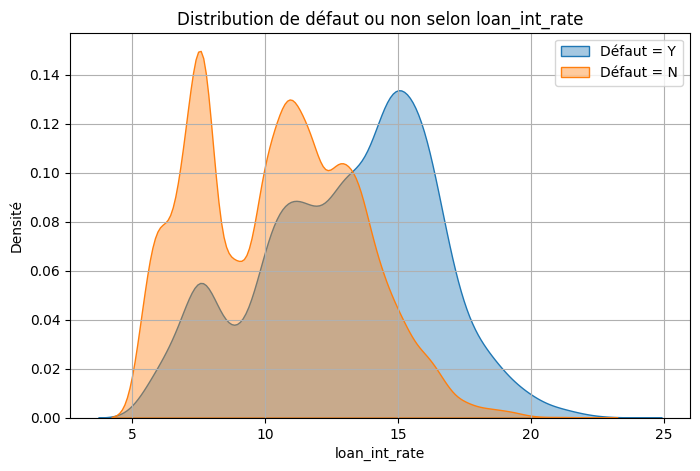

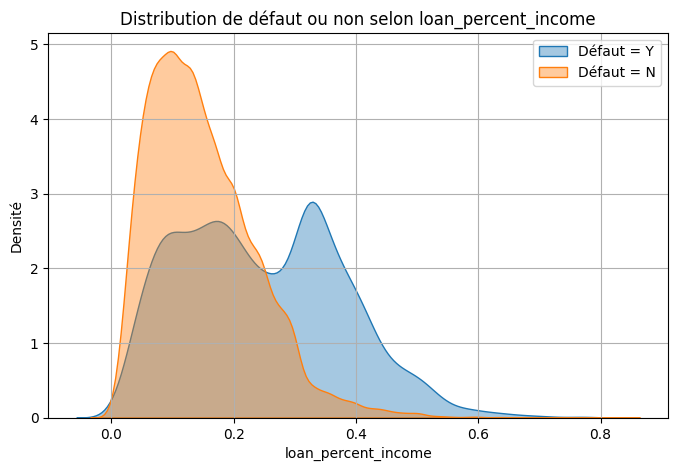

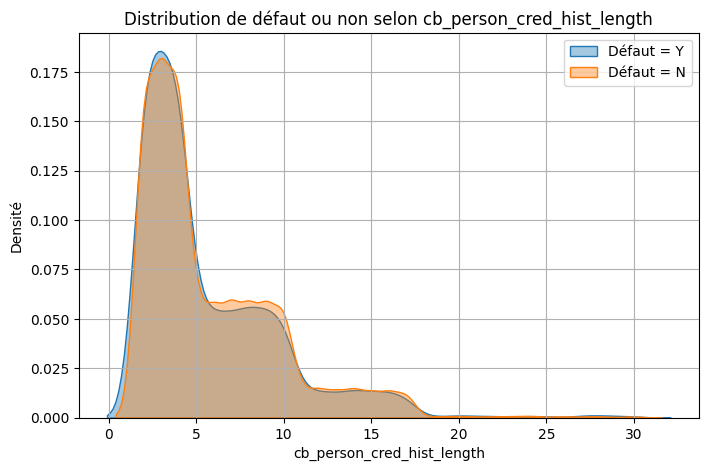

In [9]:

for col in column_num:
   
    defaut_yes = pd.to_numeric(df[df['loan_status'] == 1][col].dropna(), errors='coerce').dropna()
    defaut_no  = pd.to_numeric(df[df['loan_status'] == 0][col].dropna(), errors='coerce').dropna()

    plt.figure(figsize=(8, 5))
    sns.kdeplot(defaut_yes, fill=True, alpha=0.4, label='Défaut = Y')
    sns.kdeplot(defaut_no,  fill=True, alpha=0.4, label='Défaut = N')

    plt.xlabel(col)
    plt.ylabel('Densité')
    plt.title(f"Distribution de défaut ou non selon {col}")  
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
ks_results = []

for col in column_num:
    # Séparer les groupes
    data0 = df[df['loan_status'] == 0][col].dropna()
    data1 = df[df['loan_status'] == 1][col].dropna()
    
    # Test KS
    stat, p_value = ks_2samp(data0, data1)
    
    ks_results.append({
        'variable': col,
        'KS_stat': stat,
        'p_value': p_value
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='KS_stat', ascending=False)
print(ks_df)

## Les distributions ne sont pas indentiques (p_value < 0,05)

                     variable   KS_stat       p_value
5         loan_percent_income  0.351535  0.000000e+00
4               loan_int_rate  0.335609  0.000000e+00
1               person_income  0.280457  0.000000e+00
3                   loan_amnt  0.116821  1.617359e-66
2           person_emp_length  0.111786  9.660752e-59
0                  person_age  0.034802  2.784286e-06
6  cb_person_cred_hist_length  0.029066  1.640317e-04


## SPLIT_TRAIN_TEST

In [11]:
df['label_loan_status'] = df['loan_status'].astype('category')
df["stratify_col"] = df["label_loan_status"].astype(str) + "_" + df["person_home_ownership"].astype(str) + "_" + df["loan_intent"].astype(str) + "_" + df["cb_person_default_on_file"].astype(str)
df = df.drop(columns=["label_loan_status"])

In [12]:
counts = df["stratify_col"].value_counts()
rare_labels = counts[counts < 2].index
df["stratify_col"] = df["stratify_col"].replace(rare_labels, "Other")

In [13]:
df_train_set, df_test_set = train_test_split(df, test_size=0.2, stratify=df["stratify_col"], random_state=42)
df_train_set = df_train_set.drop(columns=["stratify_col"])
df_test_set = df_test_set.drop(columns=["stratify_col"])

In [14]:
print((df_train_set["loan_status"].value_counts())/len(df_train_set))
print((df_test_set["loan_status"].value_counts())/len(df_test_set))
(df["loan_status"].value_counts())/len(df)

loan_status
0    0.781803
1    0.218197
Name: count, dtype: float64
loan_status
0    0.781888
1    0.218112
Name: count, dtype: float64


loan_status
0    0.78182
1    0.21818
Name: count, dtype: float64

## Exploration de la base de donnée

In [15]:
df_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26059 entries, 20061 to 18759
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26059 non-null  int64  
 1   person_income               26059 non-null  int64  
 2   person_home_ownership       26059 non-null  object 
 3   person_emp_length           25346 non-null  float64
 4   loan_intent                 26059 non-null  object 
 5   loan_grade                  26059 non-null  object 
 6   loan_amnt                   26059 non-null  int64  
 7   loan_int_rate               23575 non-null  float64
 8   loan_status                 26059 non-null  int64  
 9   loan_percent_income         26059 non-null  float64
 10  cb_person_default_on_file   26059 non-null  object 
 11  cb_person_cred_hist_length  26059 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.6+ MB


In [16]:
column_num = df_train_set.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df_train_set.select_dtypes(include=['object']).columns.drop('loan_grade')
df_train_set.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,26059.000000,2.605900e+04,25346.000000,26059.000000,23575.000000,26059.000000,26059.000000,26059.000000
mean,27.719368,6.591008e+04,4.778663,9620.019955,11.015313,0.218197,0.170618,5.808857
std,6.193619,5.182004e+04,4.018198,6360.799611,3.236190,0.413030,0.106805,4.047377
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.840000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,1.900000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [17]:
df_train_set_del_missing_variable = df_train_set[(~df_train_set['loan_int_rate'].isna())&(~df_train_set['person_emp_length'].isna())].copy()
df_train_set_del_loan_int_rate = df_train_set[~df_train_set['loan_int_rate'].isna()].copy()
df_train_set_del_person_emp_length = df_train_set[~df_train_set['person_emp_length'].isna()].copy()

In [18]:
df_train_set.groupby(df_train_set['person_emp_length'].isna())['loan_status'].mean()

person_emp_length
False    0.215221
True     0.323983
Name: loan_status, dtype: float64

In [19]:
for col in column_cat:
    print((df_train_set[col].value_counts())/len(df))

person_home_ownership
RENT        0.403788
MORTGAGE    0.330079
OWN         0.063517
OTHER       0.002609
Name: count, dtype: float64
loan_intent
EDUCATION            0.158409
MEDICAL              0.149076
VENTURE              0.140357
PERSONAL             0.135599
DEBTCONSOLIDATION    0.127986
HOMEIMPROVEMENT      0.088568
Name: count, dtype: float64
cb_person_default_on_file
N    0.658992
Y    0.141002
Name: count, dtype: float64


## Discrétisation_ 1

In [20]:
dff = df_train_set.copy()

In [65]:
## Variable Age
def cat_age(data:pd.DataFrame, nb_classe:int) -> pd.DataFrame:    ## Tester avec 3 et 2 classes
    if nb_classe==3:
        conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 28.50,
                  ((data["person_age"] >= 22.50) & (data["person_age"] < 28.50))             
              ]
        choix_age = ["Jeunes instables", "seniors", "Jeunes"]
        data["classe_age"] = np.select(conditions_age, choix_age, default=None)  
    elif nb_classe==2:
         conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 22.50          
              ]
         choix_age = ["Juniors", "seniors"]
         data["classe_age"] = np.select(conditions_age, choix_age, default=None)
    return data

def cat_income(data):
    conditions_income = [data["person_income"] < 22806.00,
                     data["person_income"] >= 79993.50,
                     (data["person_income"] >= 59853.50) & (data["person_income"] < 79993.50),
                     (data["person_income"] >= 34990.00) & (data["person_income"] < 59853.50),
                     (data["person_income"] >= 22806.00) & (data["person_income"] < 34990.00)                               
              ]
    choix_income = ["(-inf, 22806.00)", "[79993.50, inf)", "[59853.50, 79993.50)", "[34990.00, 59853.50)", "[22806.00, 34990.00)"]
    data["classe_income"] = np.select(conditions_income, choix_income, default=None) # Relation monotone décroissante
    return data

def cat_emp_length(data):
    conditions_emp = [data["person_emp_length"].isna(),
                  data["person_emp_length"] < 1.50,
                  data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]

    choix_emp = ["Missing","(-inf, 1.50)", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
    data["classe_emp"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante

    #conditions_emp = [(dff["person_emp_length"].isna())|(dff["person_emp_length"] < 1.50),  # 2 ème cas : je regroupe les sans_emploi et courte durée d'emploi              
         #         dff["person_emp_length"] >= 11.50,
        #          (dff["person_emp_length"] >= 4.50) & (dff["person_emp_length"] < 11.50),
       #           (dff["person_emp_length"] >= 2.50) & (dff["person_emp_length"] < 4.50),
      #            (dff["person_emp_length"] >= 1.50) & (dff["person_emp_length"] < 2.50)
     #         ]
     # choix_emp = ["no_emp et < 1.50", ">= 11.50", "[4.50; 11.50[", "[2.50 ; 4.50[", "[1.50 ; 2.50["]
     # dff["classe_emp_2"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_amnt(data):
    conditions_amnt = [data["loan_amnt"] < 5012.50,
                     data["loan_amnt"] >= 18087.50,
                     (data["loan_amnt"] >= 14062.50) & (data["loan_amnt"] < 18087.50),
                     (data["loan_amnt"] >= 7487.50) & (data["loan_amnt"] < 14062.50),
                     (data["loan_amnt"] >= 5012.50) & (data["loan_amnt"] < 7487.50)                               
              ]

    choix_amnt = ["(-inf, 5012.50)", "[18087.50, inf)", "[14062.50, 18087.50)", "[7487.50, 14062.50)", "[5012.50, 7487.50)"]
    data["classe_amnt"] = np.select(conditions_amnt, choix_amnt, default=None)  # Relation en U (tester un autre regroupement si ce n'est pas significatif)
    return data

def cat_int_rate(data):
    conditions_int_rate = [data["loan_int_rate"].isna(),
                     data["loan_int_rate"] < 7.89,
                     data["loan_int_rate"] >= 15.28,
                     (data["loan_int_rate"] >= 14.37) & (data["loan_int_rate"] < 15.28),
                     (data["loan_int_rate"] >= 12.07) & (data["loan_int_rate"] < 14.37),
                     (data["loan_int_rate"] >= 7.89) & (data["loan_int_rate"] < 12.07)                               
              ]

    choix_int_rate = ["Missing","(-inf, 7.89)", "[15.28, inf)", "[14.37, 15.28)", "[12.07, 14.37)", "[7.89, 12.07)"]
    data["classe_int_rate"] = np.select(conditions_int_rate, choix_int_rate, default=None)  # Relation monotone croissante
    return data

def cat_percent_income(data):
    conditions_percent_income = [data["loan_percent_income"] < 0.16,
                     data["loan_percent_income"] >= 0.31,
                     (data["loan_percent_income"] >= 0.25) & (data["loan_percent_income"] < 0.31),
                     (data["loan_percent_income"] >= 0.16) & (data["loan_percent_income"] < 0.25)                               
              ]

    choix_percent_income = ["(-inf, 0.16)", "[0.31, inf)", "[0.25, 0.31)", "[0.16, 0.25)"]
    data["classe_percent_income"] = np.select(conditions_percent_income, choix_percent_income, default=None) # Relation monotone croissante
    return data

def cat_cred_hist_length(data):
    conditions_cred_hist = [data["cb_person_cred_hist_length"] < 2.50,
                     data["cb_person_cred_hist_length"] >= 4.50,
                     (data["cb_person_cred_hist_length"] >= 2.50) & (data["cb_person_cred_hist_length"] < 4.50)                               
              ]

    choix_cred_hist = ["(-inf, 2.50)", "[4.50, inf)", "[2.50, 4.50)"]
    data["classe_cred_hist"] = np.select(conditions_cred_hist, choix_cred_hist, default=None)
    return data


In [23]:
print(dff["classe_cred_hist"].value_counts())
dff.groupby(dff["classe_cred_hist"])["loan_status"].mean()

KeyError: 'classe_cred_hist'

In [48]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'classe_age',
       'classe_income', 'classe_emp', 'classe_amnt', 'classe_int_rate',
       'classe_percent_income', 'classe_cred_hist',
       'classe_person_home_ownership'],
      dtype='object')

                         Bin  Count  Count (%)  Non-event  Event  Event rate  \
0            (-inf, 5012.50)   7562   0.290188       6019   1543    0.204047   
1         [5012.50, 7487.50)   4102   0.157412       3458    644    0.156997   
2        [7487.50, 14062.50)   8963   0.343950       7143   1820    0.203057   
3       [14062.50, 18087.50)   2655   0.101884       1921    734    0.276460   
4            [18087.50, inf)   2777   0.106566       1832    945    0.340295   
5                    Special      0   0.000000          0      0    0.000000   
6                    Missing      0   0.000000          0      0    0.000000   
Totals                        26059   1.000000      20373   5686    0.218197   

             WoE        IV        JS  
0       0.084989  0.002046  0.000256  
1       0.404543  0.022846  0.002836  
2       0.091093  0.002781  0.000347  
3      -0.314111  0.010930  0.001361  
4      -0.614225  0.046850  0.005766  
5            0.0  0.000000  0.000000  
6     

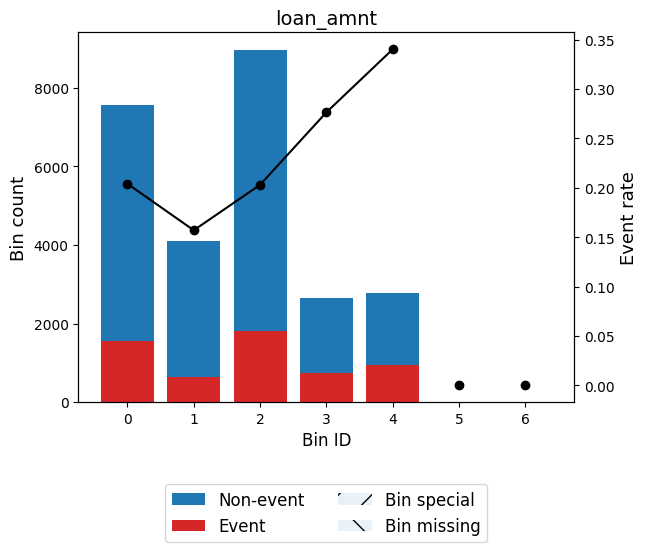

In [49]:
## GROUPEMENT VAR QUANT : L'IV mesure la capacité d’une variable à discriminer les bons et les mauvais payeurs (< 0.02 : inutile).
variable = 'loan_amnt'
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp",
                      min_n_bins=4, max_n_bins=5,monotonic_trend='auto' )  # "cp" = solver par défaut (constraint programming)
optb.fit(dff[variable], dff['loan_status'])

bin_table = optb.binning_table.build()
print(bin_table)
optb.binning_table.plot(metric="event_rate")

In [25]:
def cat_home_ownership(data):
    data["classe_person_home_ownership"] = np.where((data["person_home_ownership"]=='OTHER')|(data["person_home_ownership"]=='RENT'), "[OTHER, RENT]", data["person_home_ownership"])
    return data


In [26]:
## GROUPEMENT VAR QUAL
var = "cb_person_default_on_file"
print((dff[var].value_counts())/len(dff))
dff.groupby(dff[var])["loan_status"].mean()

cb_person_default_on_file
N    0.823746
Y    0.176254
Name: count, dtype: float64


cb_person_default_on_file
N    0.183965
Y    0.378184
Name: loan_status, dtype: float64

In [27]:
variable = 'cb_person_default_on_file'
optb = OptimalBinning(name=variable, dtype='categorical', max_n_bins=6)
optb.fit(dff[variable], dff['loan_status'])
print(optb.binning_table.build())   # voir les groupes, WoE, IV

            Bin  Count  Count (%)  Non-event  Event  Event rate       WoE  \
0           [N]  21466   0.823746      17517   3949    0.183965  0.213506   
1           [Y]   4593   0.176254       2856   1737    0.378184 -0.778941   
2       Special      0   0.000000          0      0    0.000000       0.0   
3       Missing      0   0.000000          0      0    0.000000       0.0   
Totals           26059   1.000000      20373   5686    0.218197             

              IV        JS  
0       0.035293  0.004403  
1       0.128760  0.015700  
2       0.000000  0.000000  
3       0.000000  0.000000  
Totals  0.164053  0.020103  


In [59]:
## Age
dff = cat_age(dff, 3) # IV : 0.01

## Variable person_income
dff = cat_income(dff)  # IV : 0.563203

## person_emp_length
dff = cat_emp_length(dff) # IV : 0.069434

## loan_amnt
dff = cat_amnt(dff) # IV : 0.085453

## loan_int_rate
dff = cat_int_rate(dff) # IV : 0.665547

## loan_percent_income
dff = cat_percent_income(dff) # IV : 0.943946

## cb_person_cred_hist_length
dff = cat_cred_hist_length(dff) # IV : 0.003482

In [60]:
#######  VARIABLES QUALITATIVES ###################################
## person_home_ownership
dff = cat_home_ownership(dff)

## loan_intent
# Pour l'instant on ne touche pas

## cb_person_default_on_file
# Pour l'instant on ne touche pas  # 0.164053

## ETUDES DES CORRELATIONS ENTRE LES VARIABLES

In [30]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'classe_age',
       'classe_income', 'classe_emp', 'classe_amnt', 'classe_int_rate',
       'classe_percent_income', 'classe_cred_hist',
       'classe_person_home_ownership'],
      dtype='object')

In [31]:
dff_reg = dff[['loan_status','classe_age','classe_income', 'classe_emp', 'classe_amnt','classe_int_rate', 'classe_percent_income', 'classe_cred_hist',
               'classe_person_home_ownership','loan_intent','cb_person_default_on_file']].copy()

In [53]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    p = chi2_contingency(confusion_matrix)[1]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return [np.sqrt(chi2 / (n * (min(r, k) - 1))), p]

target = 'loan_status'
features = [col for col in dff_reg.columns if col != target]

corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
chi2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for var1 in features:
    for var2 in features:
        confusion = pd.crosstab(dff_reg[var1], dff_reg[var2])
        chi2_cramer = cramers_v(confusion)
        corr_matrix.loc[var1, var2] = chi2_cramer[0]
        chi2_matrix.loc[var1, var2] = chi2_cramer[1]

chi2_matrix

,classe_age,classe_income,classe_emp,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_person_home_ownership,loan_intent,cb_person_default_on_file
classe_age,0.000000e+00,6.992307e-156,5.205598e-292,1.490320e-30,9.359182e-01,1.124655e-14,0.000000e+00,5.908120e-16,5.804437e-126,2.357329e-01
classe_income,6.992307e-156,0.000000e+00,0.000000e+00,0.000000e+00,1.561667e-15,0.000000e+00,9.276878e-55,0.000000e+00,2.303130e-49,4.553544e-08
classe_emp,5.205598e-292,0.000000e+00,0.000000e+00,9.907242e-90,2.444452e-41,5.124158e-18,5.611436e-143,0.000000e+00,6.228055e-18,1.719787e-07
classe_amnt,1.490320e-30,0.000000e+00,9.907242e-90,0.000000e+00,7.332205e-151,0.000000e+00,3.922830e-13,2.833322e-92,6.899611e-08,8.919017e-23
classe_int_rate,9.359182e-01,1.561667e-15,2.444452e-41,7.332205e-151,0.000000e+00,1.088064e-86,1.325519e-01,3.344119e-112,5.147758e-02,0.000000e+00
classe_percent_income,1.124655e-14,0.000000e+00,5.124158e-18,0.000000e+00,1.088064e-86,0.000000e+00,4.107929e-05,3.627822e-108,2.633871e-01,1.457595e-10
classe_cred_hist,0.000000e+00,9.276878e-55,5.611436e-143,3.922830e-13,1.325519e-01,4.107929e-05,0.000000e+00,2.278957e-10,2.647955e-80,3.042438e-01
classe_person_home_ownership,5.908120e-16,0.000000e+00,0.000000e+00,2.833322e-92,3.344119e-112,3.627822e-108,2.278957e-10,0.000000e+00,3.748249e-123,3.134359e-24
loan_intent,5.804437e-126,2.303130e-49,6.228055e-18,6.899611e-08,5.147758e-02,2.633871e-01,2.647955e-80,3.748249e-123,0.000000e+00,1.891977e-01
cb_person_default_on_file,2.357329e-01,4.553544e-08,1.719787e-07,8.919017e-23,0.000000e+00,1.457595e-10,3.042438e-01,3.134359e-24,1.891977e-01,0.000000e+00


In [33]:
corr_matrix

,classe_age,classe_income,classe_emp,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_person_home_ownership,loan_intent,cb_person_default_on_file
classe_age,1.000000,0.119678,0.162547,0.055433,0.009019,0.038583,0.557826,0.038561,0.108739,0.010531
classe_income,0.119678,1.000000,0.132904,0.211766,0.033360,0.194669,0.072617,0.238330,0.052561,0.039127
classe_emp,0.162547,0.132904,1.000000,0.067099,0.048813,0.037569,0.114774,0.175829,0.035168,0.037731
classe_amnt,0.055433,0.211766,0.067099,1.000000,0.086119,0.329812,0.038060,0.092976,0.026385,0.064848
classe_int_rate,0.009019,0.033360,0.048813,0.086119,1.000000,0.075980,0.016957,0.102914,0.016970,0.539444
classe_percent_income,0.038583,0.194669,0.037569,0.329812,0.075980,1.000000,0.023952,0.099465,0.015168,0.043263
classe_cred_hist,0.557826,0.072617,0.114774,0.038060,0.016957,0.023952,1.000000,0.031269,0.087889,0.009556
classe_person_home_ownership,0.038561,0.238330,0.175829,0.092976,0.102914,0.099465,0.031269,1.000000,0.107576,0.064449
loan_intent,0.108739,0.052561,0.035168,0.026385,0.016970,0.015168,0.087889,0.107576,1.000000,0.016909
cb_person_default_on_file,0.010531,0.039127,0.037731,0.064848,0.539444,0.043263,0.009556,0.064449,0.016909,0.999868


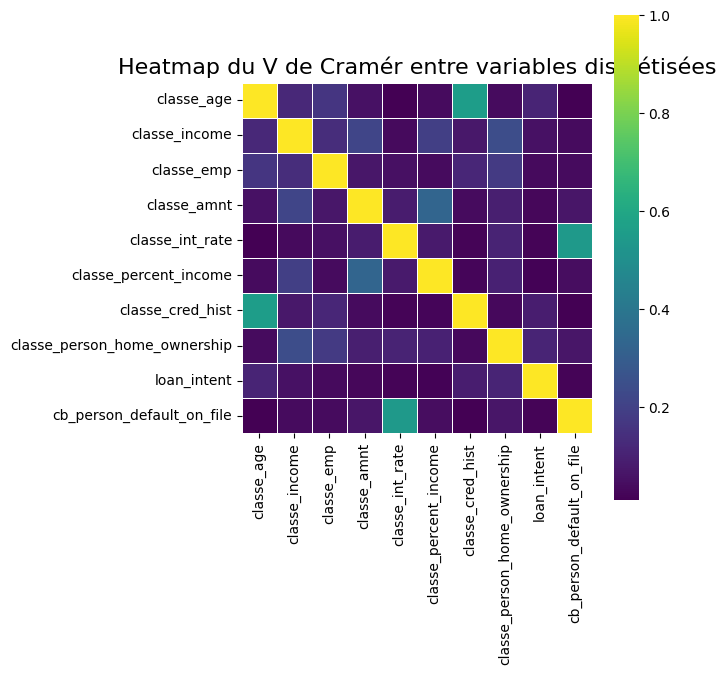

In [34]:
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix.astype(float),annot=False, cmap="viridis", square=True, linewidths=0.5)
plt.title("Heatmap du V de Cramér entre variables discrétisées", fontsize=16)
plt.tight_layout()
plt.show()

In [87]:
results_chi2_loan_status = []
for var in features:
    confusion = pd.crosstab(dff_reg[var], dff_reg[target])
    n = confusion.sum().sum()
    r, k = confusion.shape
    chi2, p, dof, expected = chi2_contingency(confusion)
    v_cramer = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    results_chi2_loan_status.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'V_de_cramer' : v_cramer
    })
    
results_chi2_loan_status = pd.DataFrame(results_chi2_loan_status)
results_chi2_loan_status

,variable,chi2,p_value,V_de_cramer
0,classe_age,46.836383,6.754742e-11,0.042395
1,classe_income,2674.434023,0.000000e+00,0.320359
2,classe_emp,317.277908,2.028227e-67,0.110342
3,classe_amnt,406.505464,1.093019e-86,0.124898
4,classe_int_rate,3367.347696,0.000000e+00,0.359472
5,classe_percent_income,5040.381585,0.000000e+00,0.439798
6,classe_cred_hist,15.616729,4.063220e-04,0.024480
7,classe_person_home_ownership,1521.821807,0.000000e+00,0.241659
8,loan_intent,416.441077,8.477017e-88,0.126415
9,cb_person_default_on_file,835.478008,1.044023e-183,0.179056


- **Age** préféré à **cred_hist** *(IV_age > IV_cred_hist)*
- **loan_int_rate** préféré à **cb_person_default_on_file** *(IV_rate > IV_default_on_file)*

## MODELISATION

In [61]:
#,'classe_cred_hist'
features = [ 'classe_age','classe_income','classe_emp','classe_amnt','classe_int_rate','classe_percent_income','classe_person_home_ownership','loan_intent',
    'cb_person_default_on_file']
target = "loan_status"
X = dff_reg[features]
y = dff_reg[target]

In [62]:
cat_vars = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_vars)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000))
])
model.fit(X, y)
print("Score train :", model.score(X, y))

Score train : 0.8727119229440884


In [63]:
## VOIR LES COEFS
cat_vars = X.columns.tolist()

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_final = pd.DataFrame(ohe.fit_transform(X[cat_vars]), columns=ohe.get_feature_names_out(cat_vars), index=X.index)

# Ajouter constante pour statsmodels
X_final = sm.add_constant(X_final)

# =============================
# 3. Fit régression logistique
# =============================
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()

# =============================
# 4. Résultats : coefficients, p-values, odds ratio
# =============================
summary_df = pd.DataFrame({
    'variable': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues,
    'odds_ratio': result.params.apply(lambda x: round(np.exp(x), 3))
}).sort_values(by='coefficient', ascending=False)

Optimization terminated successfully.
         Current function value: 0.324585
         Iterations 7


In [64]:
summary_df

,variable,coefficient,p_value,odds_ratio
"classe_int_rate_[15.28, inf)","classe_int_rate_[15.28, inf)",3.127664,0.000000e+00,22.821
"classe_percent_income_[0.31, inf)","classe_percent_income_[0.31, inf)",3.061574,3.379873e-219,21.361
"classe_int_rate_[14.37, 15.28)","classe_int_rate_[14.37, 15.28)",2.395710,6.380904e-152,10.976
classe_int_rate_Missing,classe_int_rate_Missing,0.891040,4.259908e-26,2.438
"classe_int_rate_[12.07, 14.37)","classe_int_rate_[12.07, 14.37)",0.885445,7.406730e-33,2.424
"classe_person_home_ownership_[OTHER, RENT]","classe_person_home_ownership_[OTHER, RENT]",0.832473,1.259805e-72,2.299
"classe_int_rate_[7.89, 12.07)","classe_int_rate_[7.89, 12.07)",0.438009,8.370264e-11,1.550
"classe_percent_income_[0.25, 0.31)","classe_percent_income_[0.25, 0.31)",0.424858,6.984811e-07,1.529
"classe_percent_income_[0.16, 0.25)","classe_percent_income_[0.16, 0.25)",0.303621,1.015028e-06,1.355
cb_person_default_on_file_Y,cb_person_default_on_file_Y,0.239333,5.514497e-06,1.270


CORRECTION CLEMENT AFFICHAGE REG

In [105]:
from typing import Dict, Tuple, Any

def encode_vars(data: pd.DataFrame, features: list, refs: Dict[str, str]) -> pd.DataFrame:
    """One-hot encoding avec références choisies."""
    dfs = []
    for var in features:
        ref = refs[var]
        for mod in data[var].unique():
            if mod != ref:
                dfs.append(pd.DataFrame(
                    {f"{var}_{mod}": (data[var] == mod).astype(int)},
                    index=data.index  # ← IMPORTANT : garder l'index
                ))
    return pd.concat(dfs, axis=1)


def find_optimal_refs(data: pd.DataFrame, features: list, target: str = 'loan_status') -> Tuple[Dict, Any]:
    """Trouve les références qui donnent tous les coefficients négatifs."""
    
    # Régression exploratoire
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    X = pd.DataFrame(
        ohe.fit_transform(data[features]),
        columns=ohe.get_feature_names_out(features),
        index=data.index  # ← IMPORTANT : garder l'index
    )
    model_temp = sm.Logit(data[target], sm.add_constant(X)).fit(disp=0)
    
    # Trouver les modalités avec coef max par variable
    refs = {}
    for var in features:
        mods = sorted(data[var].unique())
        coefs = {}
        
        for mod in mods:
            col = f"{var}_{mod}"
            coefs[mod] = model_temp.params.get(col, 0.0)
        
        refs[var] = max(coefs, key=coefs.get)
    
    # Régression finale avec les bonnes références
    X_final = encode_vars(data, features, refs)
    model_final = sm.Logit(data[target], sm.add_constant(X_final)).fit(disp=0)
    
    return refs, model_final


def build_results_table(model, refs: Dict[str, str]) -> pd.DataFrame:
    """Construit le tableau de résultats complet avec les références."""
    
    # Modalités encodées
    df = pd.DataFrame({
        'modalite': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values,
        'OR': np.exp(model.params.values)
    })
    
    # Ajouter les références
    ref_rows = [
        {'modalite': f"{v}_{m}", 'coef': 0.0, 'pval': 0.0, 'OR': 1.0}
        for v, m in refs.items()
    ]
    
    result = pd.concat([df, pd.DataFrame(ref_rows)], ignore_index=True)
    
    # Trier par modalité
    result = result.sort_values('modalite')
    
    return result[['modalite', 'coef', 'pval', 'OR']]

In [106]:
refs, model = find_optimal_refs(dff_reg, features)
results = build_results_table(model, refs)
print((results['coef'] > 0).sum())  # Doit être 0
results.to_csv('results.csv')

1


In [107]:
results 

,modalite,coef,pval,OR
30,cb_person_default_on_file_N,-0.239333,5.514497e-06,0.787153
39,cb_person_default_on_file_Y,0.000000,0.000000e+00,1.000000
1,classe_age_Jeunes,-0.073060,2.107929e-01,0.929545
31,classe_age_Jeunes instables,0.000000,0.000000e+00,1.000000
2,classe_age_seniors,-0.149384,1.773075e-02,0.861239
11,"classe_amnt_(-inf, 5012.50)",-0.029218,8.049692e-01,0.971205
13,"classe_amnt_[14062.50, 18087.50)",-0.100062,2.366173e-01,0.904782
34,"classe_amnt_[18087.50, inf)",0.000000,0.000000e+00,1.000000
12,"classe_amnt_[5012.50, 7487.50)",-0.315825,3.803807e-03,0.729187
14,"classe_amnt_[7487.50, 14062.50)",-0.200730,1.476638e-02,0.818133


In [50]:
def decoupage_quantile(df,var,n_bins):
    df[var+'_bin'] = pd.qcut(df[var], q=n_bins, duplicates='drop')
    group = df.groupby(var+'_bin')['loan_status'].agg(['count', 'sum']).rename(columns={'sum': 'events'})
    group['event_rate'] = group['events'] / group['count']
    group = group.reset_index().rename(columns={'index': 'person_age_bin'})

    bins_labels = group[var+'_bin'].astype(str).tolist()
    event_rates = group['event_rate'].values

    plt.figure(figsize=(8,5))
    plt.bar(bins_labels, event_rates)
    plt.xlabel("Bins d'âge")
    plt.ylabel("Event rate (taux de défaut)")
    plt.title("Taux de défaut par bin (âge)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

C:\Users\feuss\AppData\Local\Temp\ipykernel_8288\1815756755.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(var+'_bin')['loan_status'].agg(['count', 'sum']).rename(columns={'sum': 'events'})


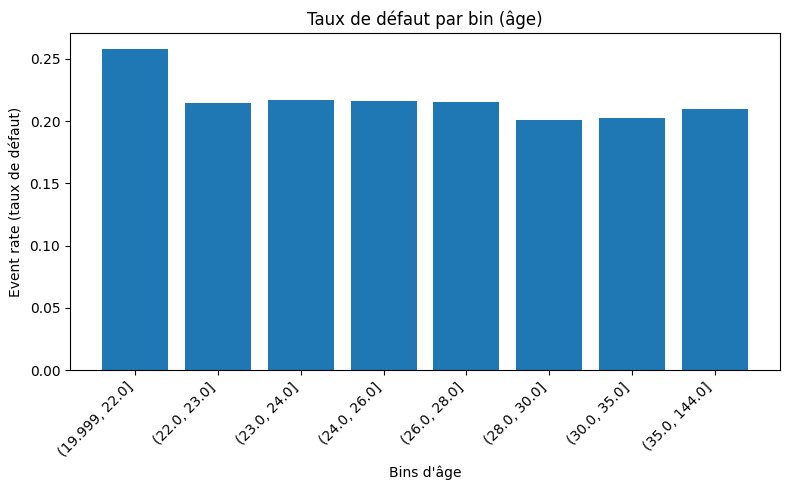

In [53]:
decoupage_quantile(dff, 'person_age', 8)

In [58]:
dff = dff.drop("person_age_bin", axis=1)